# Assignment 2 — Feature Extraction Analysis of a Pre-trained DNN (MobileNetV2)
### Before vs. After Fine-tuning, on Face Recognition (LFW) and Object/Flower Recognition (CIFAR-10)

**Model:** MobileNetV2 (ImageNet pre-trained)
**Penultimate-layer features** are extracted before and after fine-tuning, reduced to 2D with PCA / t-SNE / UMAP, and visualized and compared quantitatively (silhouette score) and qualitatively.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [1]:
!pip install umap-learn -q

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import gc

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import umap.umap_ as umap

IMG_SIZE = 160
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Face Recognition Task — Data (LFW, publicly available)

In [2]:
lfw = fetch_lfw_people(min_faces_per_person=50)

X = lfw.images
y = lfw.target

# Limit data for Colab memory/runtime constraints
X = X[:800]
y = y[:800]

# Grayscale -> RGB, resize, MobileNetV2 preprocessing
X = np.array([cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) for img in X])
X = np.array([cv2.resize(img, (IMG_SIZE, IMG_SIZE)) for img in X])
X = preprocess_input(X.astype(np.float32))

# FIX: stratify to keep identity class balance across train/val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Face classes:", len(np.unique(y)), "| Train:", X_train.shape, "| Val:", X_val.shape)


Face classes: 12 | Train: (640, 160, 160, 3) | Val: (160, 160, 160, 3)


In [3]:
def extract_features_batch(model, X, batch_size=32):
    features = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size]
        feat = model.predict(batch, verbose=0)
        features.append(feat)
    return np.vstack(features)


### 1a. Feature extraction — BEFORE fine-tuning (ImageNet weights only)

In [4]:
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

features_face_before = extract_features_batch(base_model, X_val)
print("Face BEFORE features:", features_face_before.shape)


/tmp/ipykernel_2642/1342385684.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Face BEFORE features: (160, 1280)


### 1b. Fine-tune MobileNetV2 on LFW identities

In [5]:
num_classes = len(np.unique(y))

x = base_model.output
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# Partial freeze: keep early generic filters frozen, fine-tune last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_face = model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))


Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.3094 - loss: 2.2061 - val_accuracy: 0.3313 - val_loss: 2.3417
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 935ms/step - accuracy: 0.3516 - loss: 2.0914 - val_accuracy: 0.0625 - val_loss: 2.4183
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 960ms/step - accuracy: 0.3938 - loss: 1.9303 - val_accuracy: 0.0625 - val_loss: 2.5332
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4500 - loss: 1.7688 - val_accuracy: 0.3250 - val_loss: 2.3439
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.4781 - loss: 1.6806 - val_accuracy: 0.3313 - val_loss: 2.3838
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5031 - loss: 1.5584 - val_accuracy: 0.1562 - val_loss: 2.6850
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5469 - loss: 1.4467 - val_accuracy: 0.1562 - val_loss: 2.8888
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5641 - loss: 1.3789 - val_accuracy: 0.1562 - val

### 1c. Feature extraction — AFTER fine-tuning

In [6]:
feature_model = models.Model(inputs=model.input, outputs=model.layers[-2].output)

features_face_after = extract_features_batch(feature_model, X_val)
print("Face AFTER features:", features_face_after.shape)

gc.collect()


Face AFTER features: (160, 128)


2182

## 2. Object Recognition Task (Flowers) — Data (CIFAR-10, publicly available)

In [7]:
(X_train_c, y_train_c), (_, _) = cifar10.load_data()

# Limit data for Colab memory/runtime constraints
X_train_c = X_train_c[:1000]
y_train_c = y_train_c[:1000]

def preprocess_cifar(X, size=IMG_SIZE):
    data = []
    for img in X:
        img = cv2.resize(img, (size, size))
        data.append(img)
    data = np.array(data).astype(np.float32)
    return preprocess_input(data)

X_train_c = preprocess_cifar(X_train_c)
y_train_c = y_train_c.flatten()

print("CIFAR-10 train:", X_train_c.shape, "classes:", len(np.unique(y_train_c)))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1317s 8us/step
CIFAR-10 train: (1000, 160, 160, 3) classes: 10


### 2a. Feature extraction — BEFORE fine-tuning
**FIX:** `base_model_cifar` is now defined *before* it is used (original notebook referenced it before its definition, which raised a `NameError`).

In [8]:
base_model_cifar = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

features_cifar_before = extract_features_batch(base_model_cifar, X_train_c)
print("CIFAR BEFORE features:", features_cifar_before.shape)


/tmp/ipykernel_2642/2369135331.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_cifar = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


CIFAR BEFORE features: (1000, 1280)


### 2b. Fine-tune MobileNetV2 on CIFAR-10

In [9]:
x = base_model_cifar.output
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(10, activation='softmax')(x)

model_cifar = models.Model(inputs=base_model_cifar.input, outputs=output)

# Partial freeze, mirroring the face model setup
for layer in base_model_cifar.layers[:-30]:
    layer.trainable = False
for layer in base_model_cifar.layers[-30:]:
    layer.trainable = True

model_cifar.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

y_train_cat = to_categorical(y_train_c, num_classes=10)
history_cifar = model_cifar.fit(X_train_c, y_train_cat, epochs=30)


Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 794ms/step - accuracy: 0.2850 - loss: 2.1288
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 786ms/step - accuracy: 0.6760 - loss: 1.0825
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 807ms/step - accuracy: 0.7940 - loss: 0.7053
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 794ms/step - accuracy: 0.8670 - loss: 0.4701
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 791ms/step - accuracy: 0.9100 - loss: 0.3453
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 799ms/step - accuracy: 0.9340 - loss: 0.2580
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 795ms/step - accuracy: 0.9680 - loss: 0.1556
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 785ms/step - accuracy: 0.9600 - loss: 0.1555
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9750 - loss: 0.1241
Epoch 10/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 66s 807ms/step - accuracy: 0.9870 - loss: 0.0778
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 781ms/step - accuracy: 0.9910 - loss: 0.0631
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 7

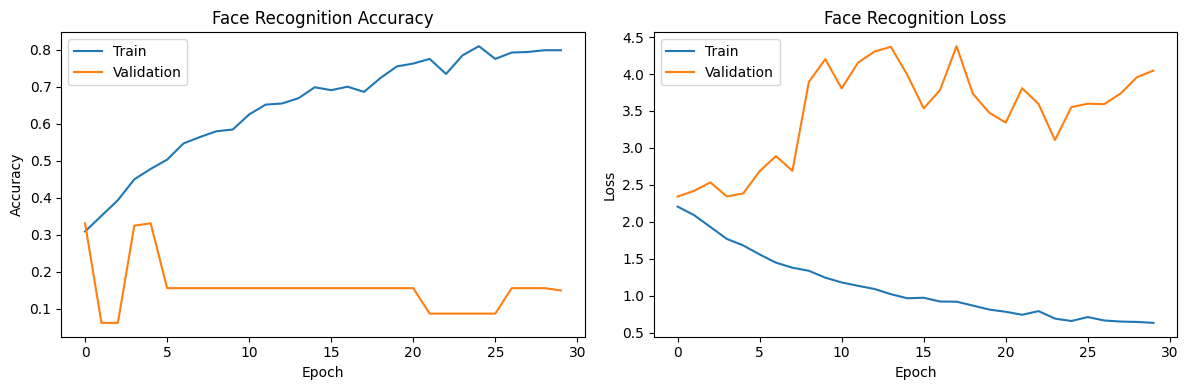

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_face.history['accuracy'], label='Train')
plt.plot(history_face.history['val_accuracy'], label='Validation')
plt.title("Face Recognition Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_face.history['loss'], label='Train')
plt.plot(history_face.history['val_loss'], label='Validation')
plt.title("Face Recognition Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### 2c. Feature extraction — AFTER fine-tuning

In [11]:
feature_model_cifar = models.Model(
    inputs=model_cifar.input,
    outputs=model_cifar.layers[-2].output
)

features_cifar_after = extract_features_batch(feature_model_cifar, X_train_c)
print("CIFAR AFTER features:", features_cifar_after.shape)

gc.collect()


CIFAR AFTER features: (1000, 128)


10077

## 3. Custom Test Sets (your own images)
**FIX:** `cv2.imread` loads images in BGR order. The training pipelines above use RGB (LFW converted explicitly, CIFAR-10 stored natively as RGB). Without converting BGR→RGB here, the test images would be fed to the network with swapped colour channels relative to what it was trained on — silently corrupting every test-set embedding. This is fixed below.

**Also added:** test images are now passed through both the BEFORE (ImageNet-only) and AFTER (fine-tuned) models, so the before/after comparison is complete for the actual held-out test set, not just the validation split.

In [12]:
def load_custom_images(path, size=IMG_SIZE):
    images = []
    labels = []
    classes = sorted(os.listdir(path))

    for i, cls in enumerate(classes):
        folder = os.path.join(path, cls)
        if not os.path.isdir(folder):
            continue
        for file in os.listdir(folder):
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            # FIX: BGR (cv2 default) -> RGB to match training-time preprocessing
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (size, size))

            images.append(img)
            labels.append(i)

    images = np.array(images).astype(np.float32)
    images = preprocess_input(images)
    return images, np.array(labels), classes


In [15]:
X_face_test, y_face_test, face_test_classes = load_custom_images(
    "/content/drive/MyDrive/dataset/person"
)

features_face_test_before = extract_features_batch(base_model, X_face_test)
features_face_test_after  = extract_features_batch(feature_model, X_face_test)

print("Face test set:", X_face_test.shape, "| identities:", face_test_classes)


Face test set: (35, 160, 160, 3) | identities: ['al-amin', 'reeky', 'saba', 'sania', 'shawda', 'shawon', 'sifat']


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
X_flower_test, y_flower_test, flower_test_classes = load_custom_images(
    "/content/drive/MyDrive/dataset/flowers"
)

features_flower_test_before = extract_features_batch(base_model_cifar, X_flower_test)
features_flower_test_after  = extract_features_batch(feature_model_cifar, X_flower_test)

print("Flower test set:", X_flower_test.shape, "| categories:", flower_test_classes)


Flower test set: (25, 160, 160, 3) | categories: ['flower1', 'flower2', 'flower3', 'flower4', 'flower5']


## 4. Dimensionality Reduction (PCA / t-SNE / UMAP)
**FIX:** added `random_state` to UMAP for reproducibility, and a silhouette-score helper for the quantitative comparison requested in the assignment (clustering quality before vs. after).

In [17]:
def reduce_features_safe(features, labels, limit=500):
    limit = min(limit, len(features))
    features = features[:limit]
    labels = labels[:limit]

    n_samples = len(features)
    perplexity = min(30, max(5, n_samples // 3))

    results = {}
    results["PCA"] = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(features)
    results["TSNE"] = TSNE(
        n_components=2, perplexity=perplexity, random_state=RANDOM_STATE, init='pca'
    ).fit_transform(features)
    results["UMAP"] = umap.UMAP(
        n_neighbors=10, min_dist=0.3, random_state=RANDOM_STATE
    ).fit_transform(features)

    return results, labels


def silhouette_table(reduced_dict, labels, tag):
    rows = []
    for name, emb in reduced_dict.items():
        try:
            score = silhouette_score(emb, labels)
        except Exception:
            score = float('nan')
        rows.append((tag, name, score))
    return rows


In [18]:
def plot_results(data_dict, labels, title):
    for name, data in data_dict.items():
        plt.figure(figsize=(6, 5))
        scatter = plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab20', s=18)
        plt.title(f"{title} - {name}")
        plt.xlabel("Component 1")
        plt.ylabel("Component 2")
        plt.colorbar(scatter, label="Class")
        plt.show()


## 5. Apply Reduction & Visualize — Face Recognition

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


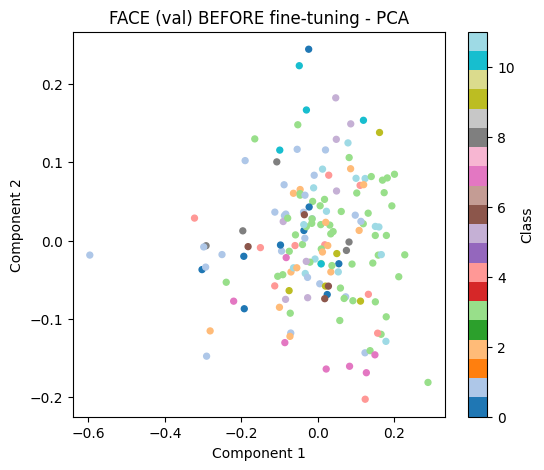

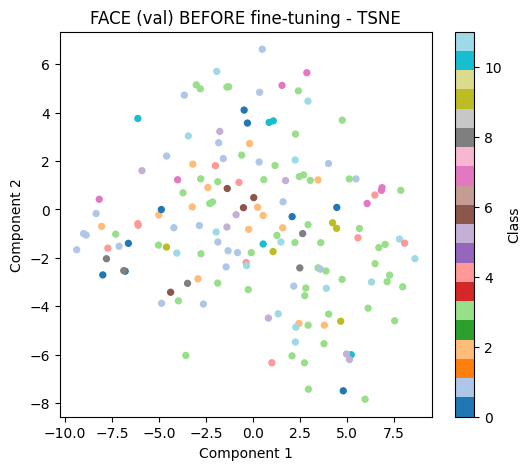

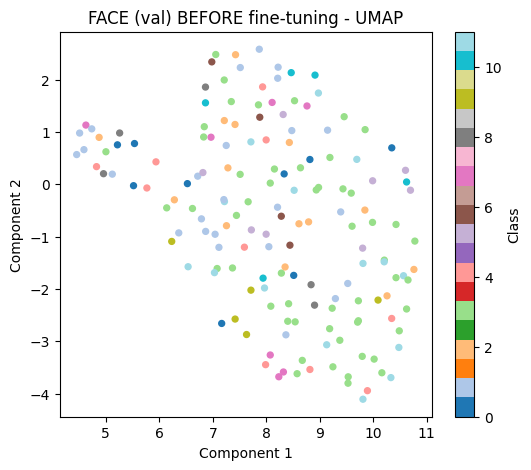

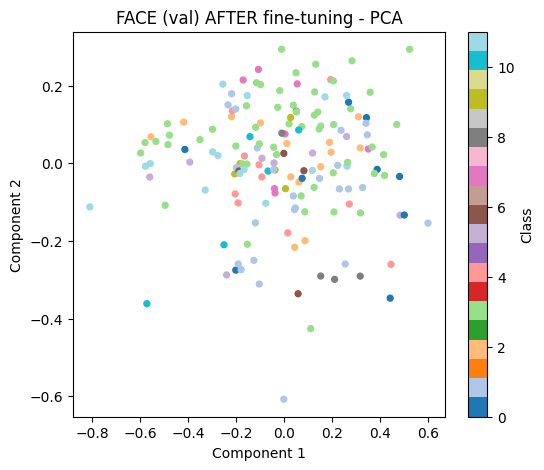

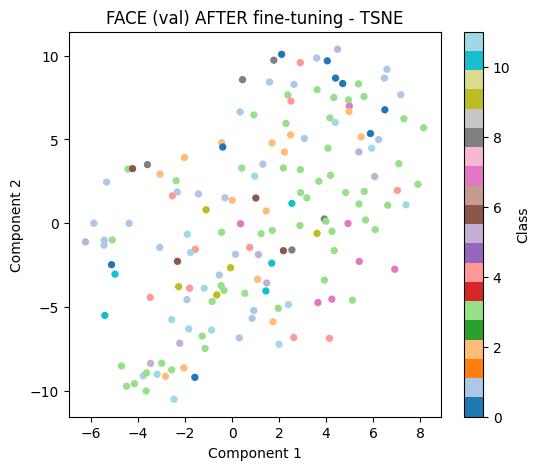

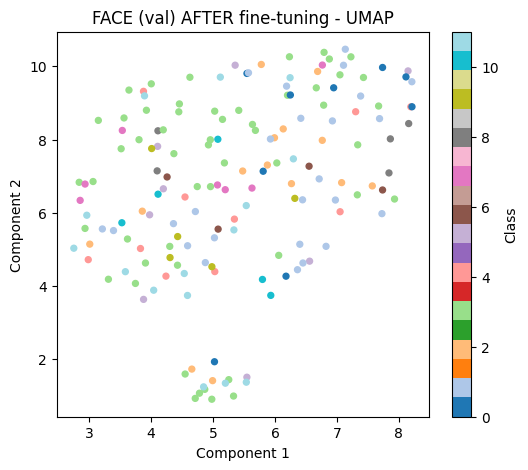

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


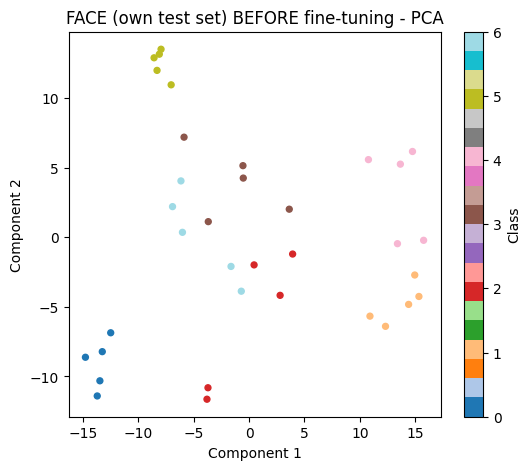

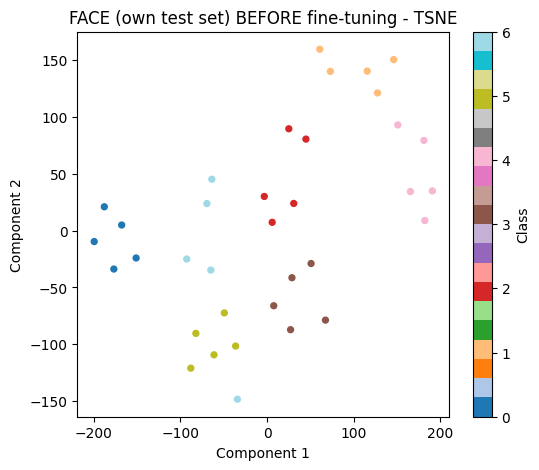

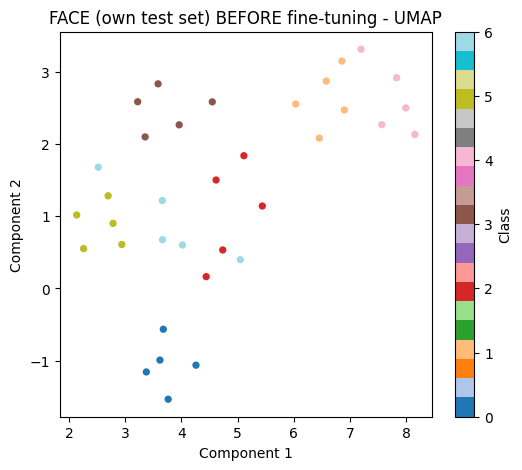

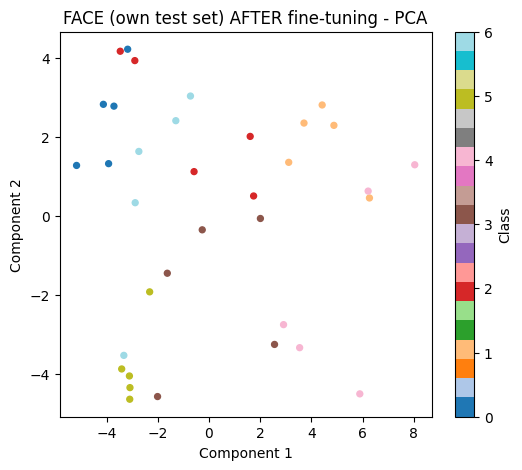

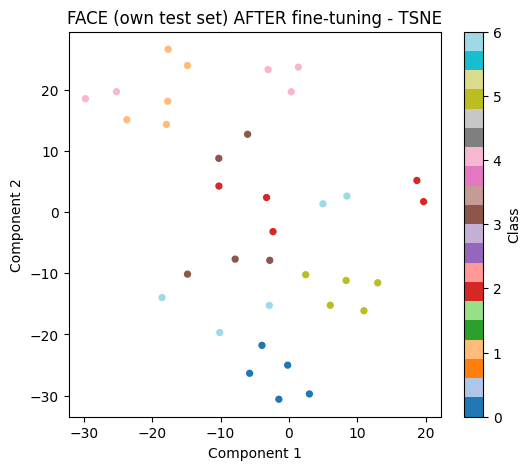

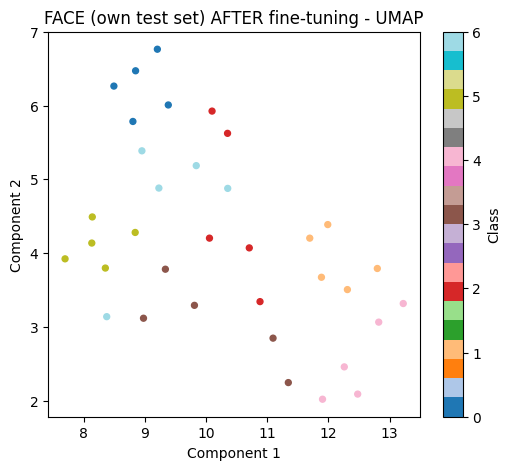

In [19]:
face_before_reduced, lbl_face_val = reduce_features_safe(features_face_before, y_val)
face_after_reduced, _ = reduce_features_safe(features_face_after, y_val)

plot_results(face_before_reduced, lbl_face_val, "FACE (val) BEFORE fine-tuning")
plot_results(face_after_reduced, lbl_face_val, "FACE (val) AFTER fine-tuning")

face_test_before_reduced, lbl_face_test = reduce_features_safe(
    features_face_test_before, y_face_test, limit=len(y_face_test)
)
face_test_after_reduced, _ = reduce_features_safe(
    features_face_test_after, y_face_test, limit=len(y_face_test)
)

plot_results(face_test_before_reduced, lbl_face_test, "FACE (own test set) BEFORE fine-tuning")
plot_results(face_test_after_reduced, lbl_face_test, "FACE (own test set) AFTER fine-tuning")


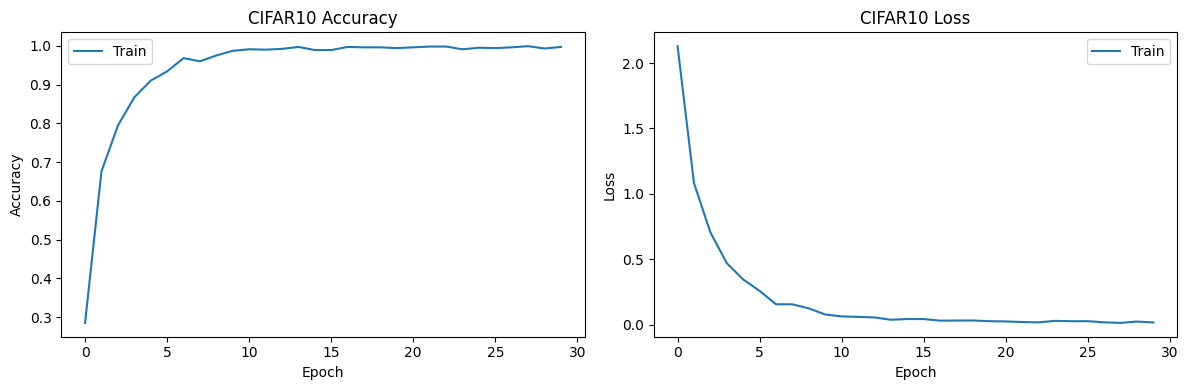

In [20]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_cifar.history['accuracy'], label='Train')
plt.title("CIFAR10 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cifar.history['loss'], label='Train')
plt.title("CIFAR10 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 6. Apply Reduction & Visualize — CIFAR-10 / Flowers

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


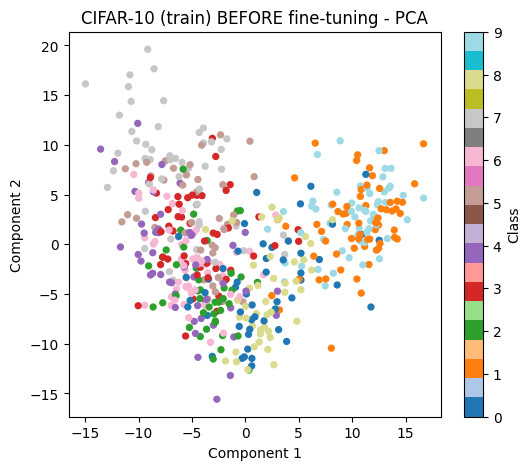

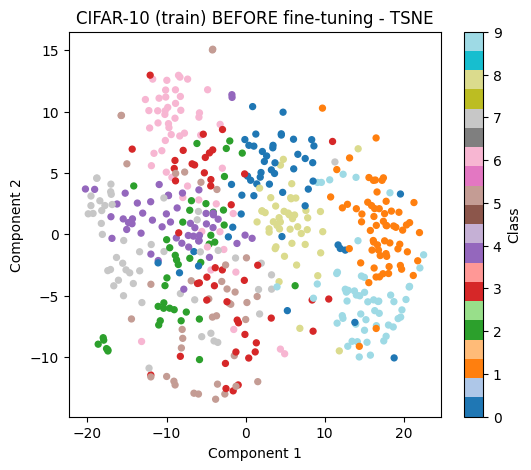

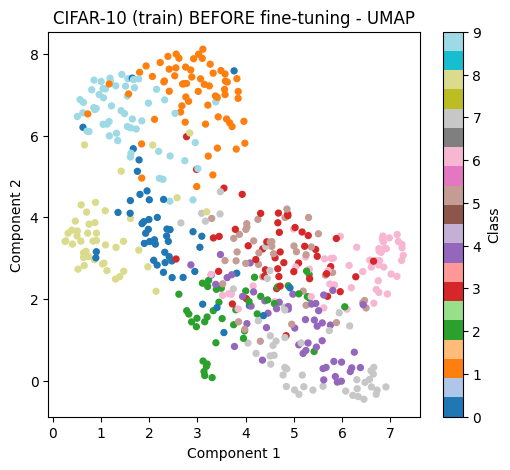

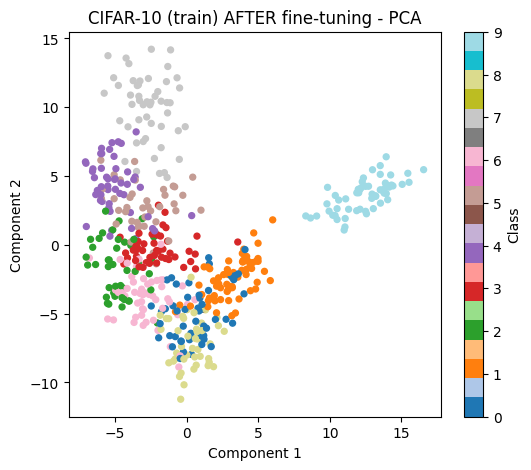

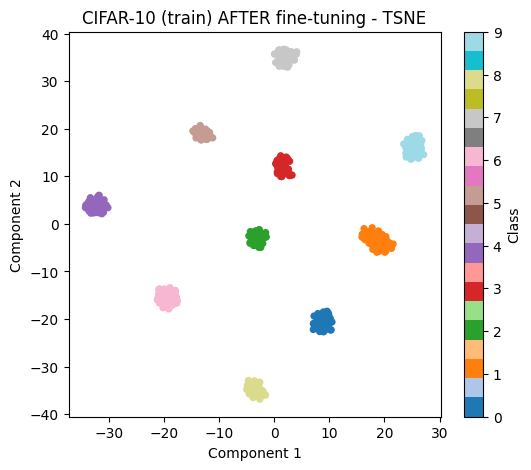

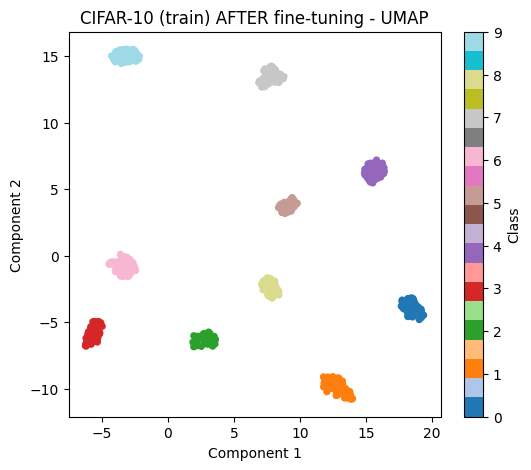

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


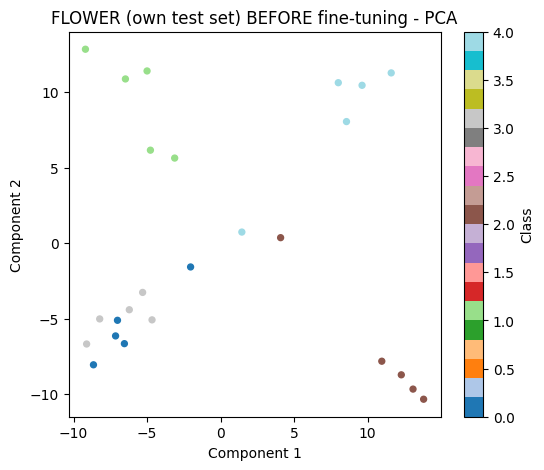

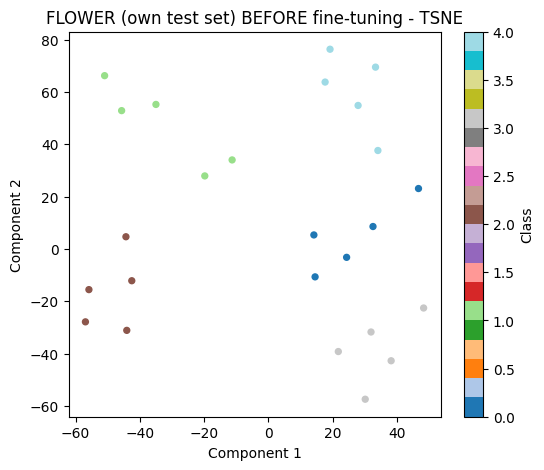

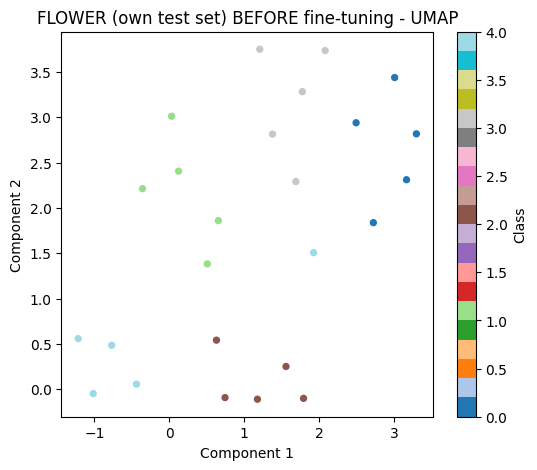

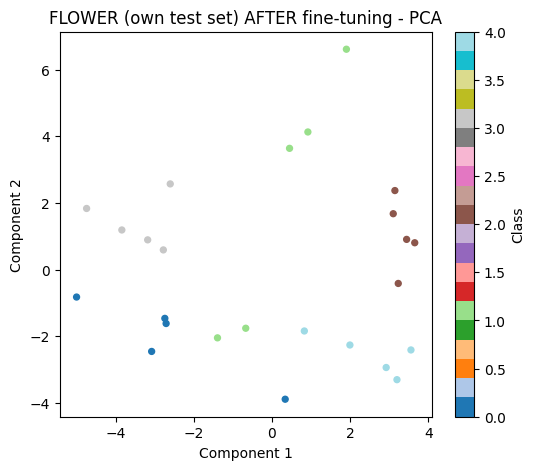

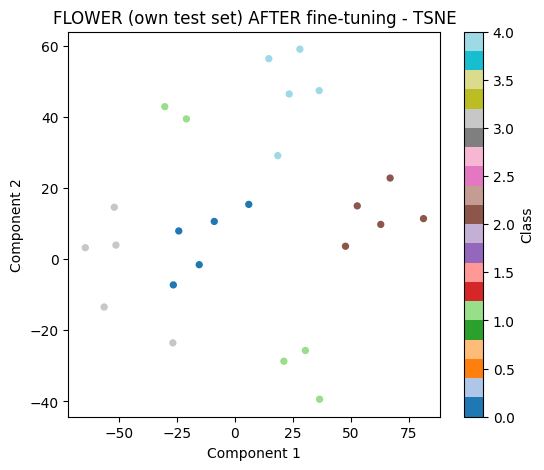

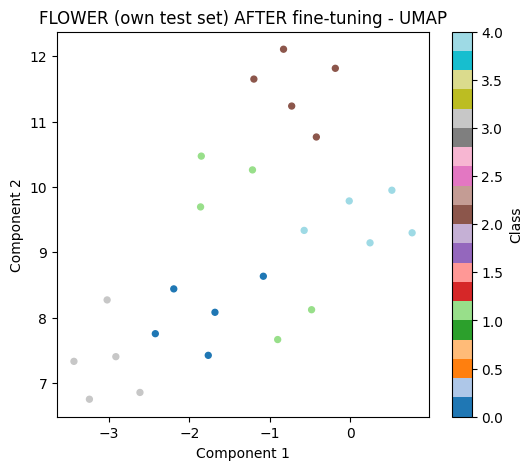

In [21]:
cifar_before_reduced, lbl_cifar = reduce_features_safe(features_cifar_before, y_train_c)
cifar_after_reduced, _ = reduce_features_safe(features_cifar_after, y_train_c)

plot_results(cifar_before_reduced, lbl_cifar, "CIFAR-10 (train) BEFORE fine-tuning")
plot_results(cifar_after_reduced, lbl_cifar, "CIFAR-10 (train) AFTER fine-tuning")

flower_test_before_reduced, lbl_flower_test = reduce_features_safe(
    features_flower_test_before, y_flower_test, limit=len(y_flower_test)
)
flower_test_after_reduced, _ = reduce_features_safe(
    features_flower_test_after, y_flower_test, limit=len(y_flower_test)
)

plot_results(flower_test_before_reduced, lbl_flower_test, "FLOWER (own test set) BEFORE fine-tuning")
plot_results(flower_test_after_reduced, lbl_flower_test, "FLOWER (own test set) AFTER fine-tuning")


## 7. Comparative Visualization — Before vs. After, side by side

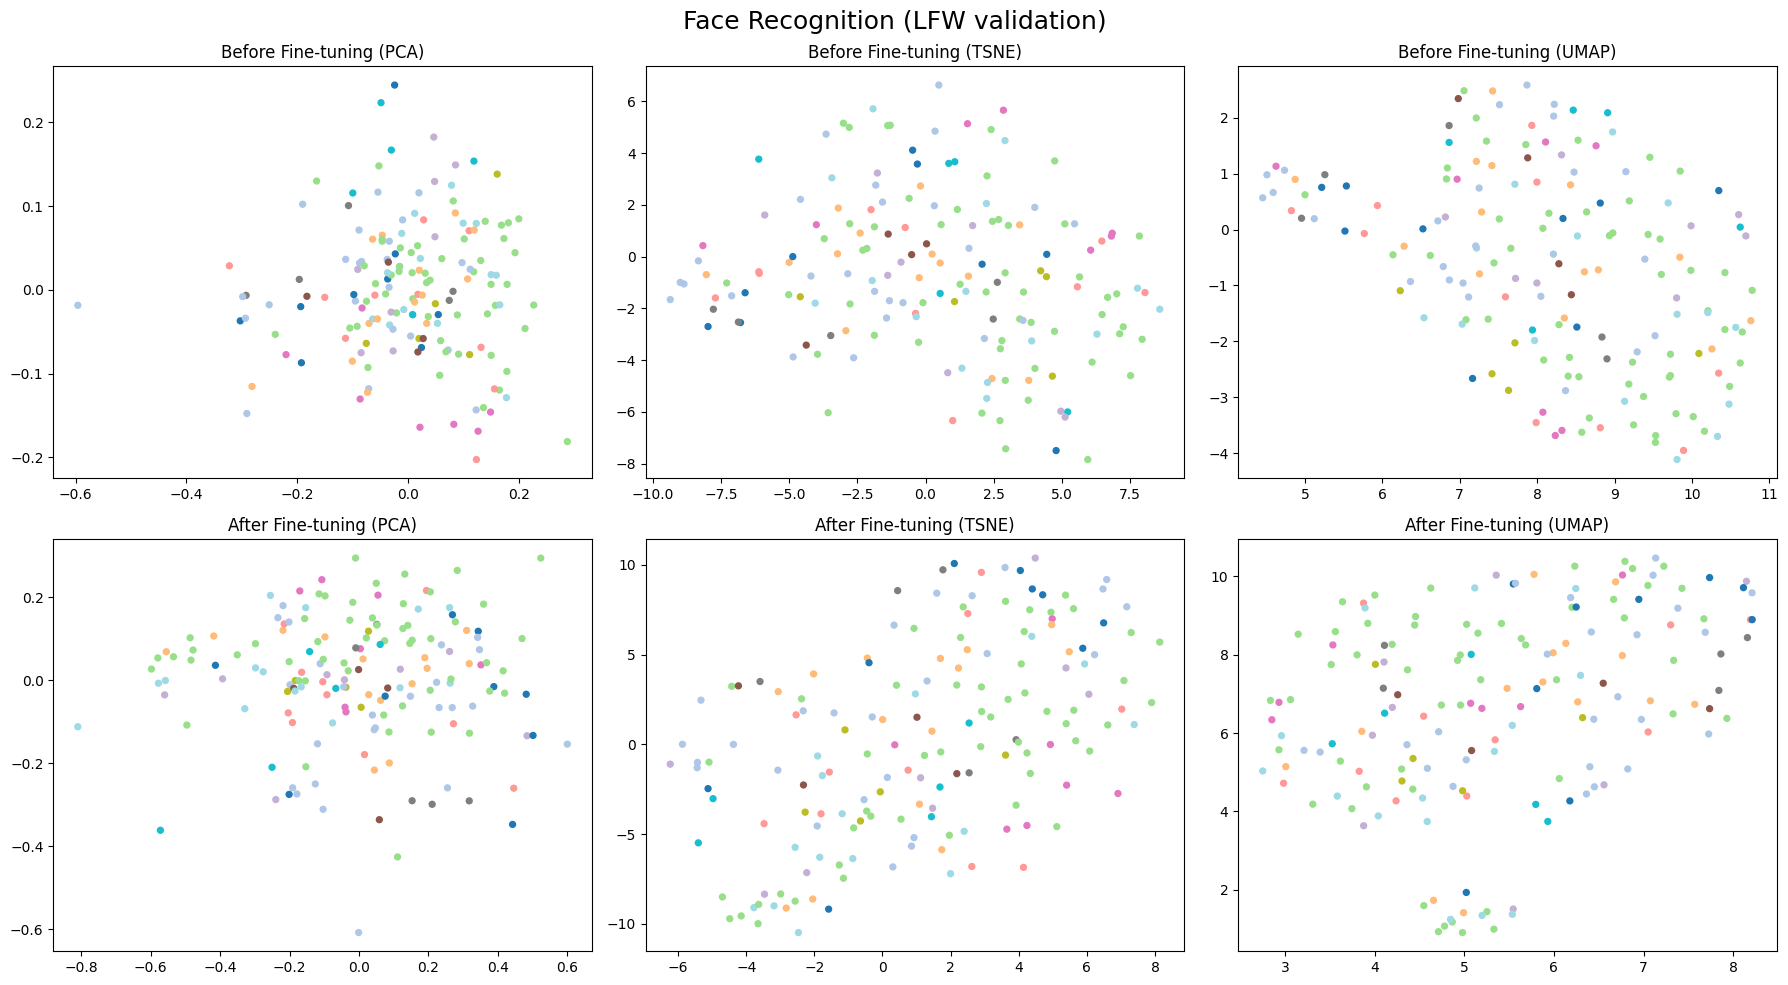

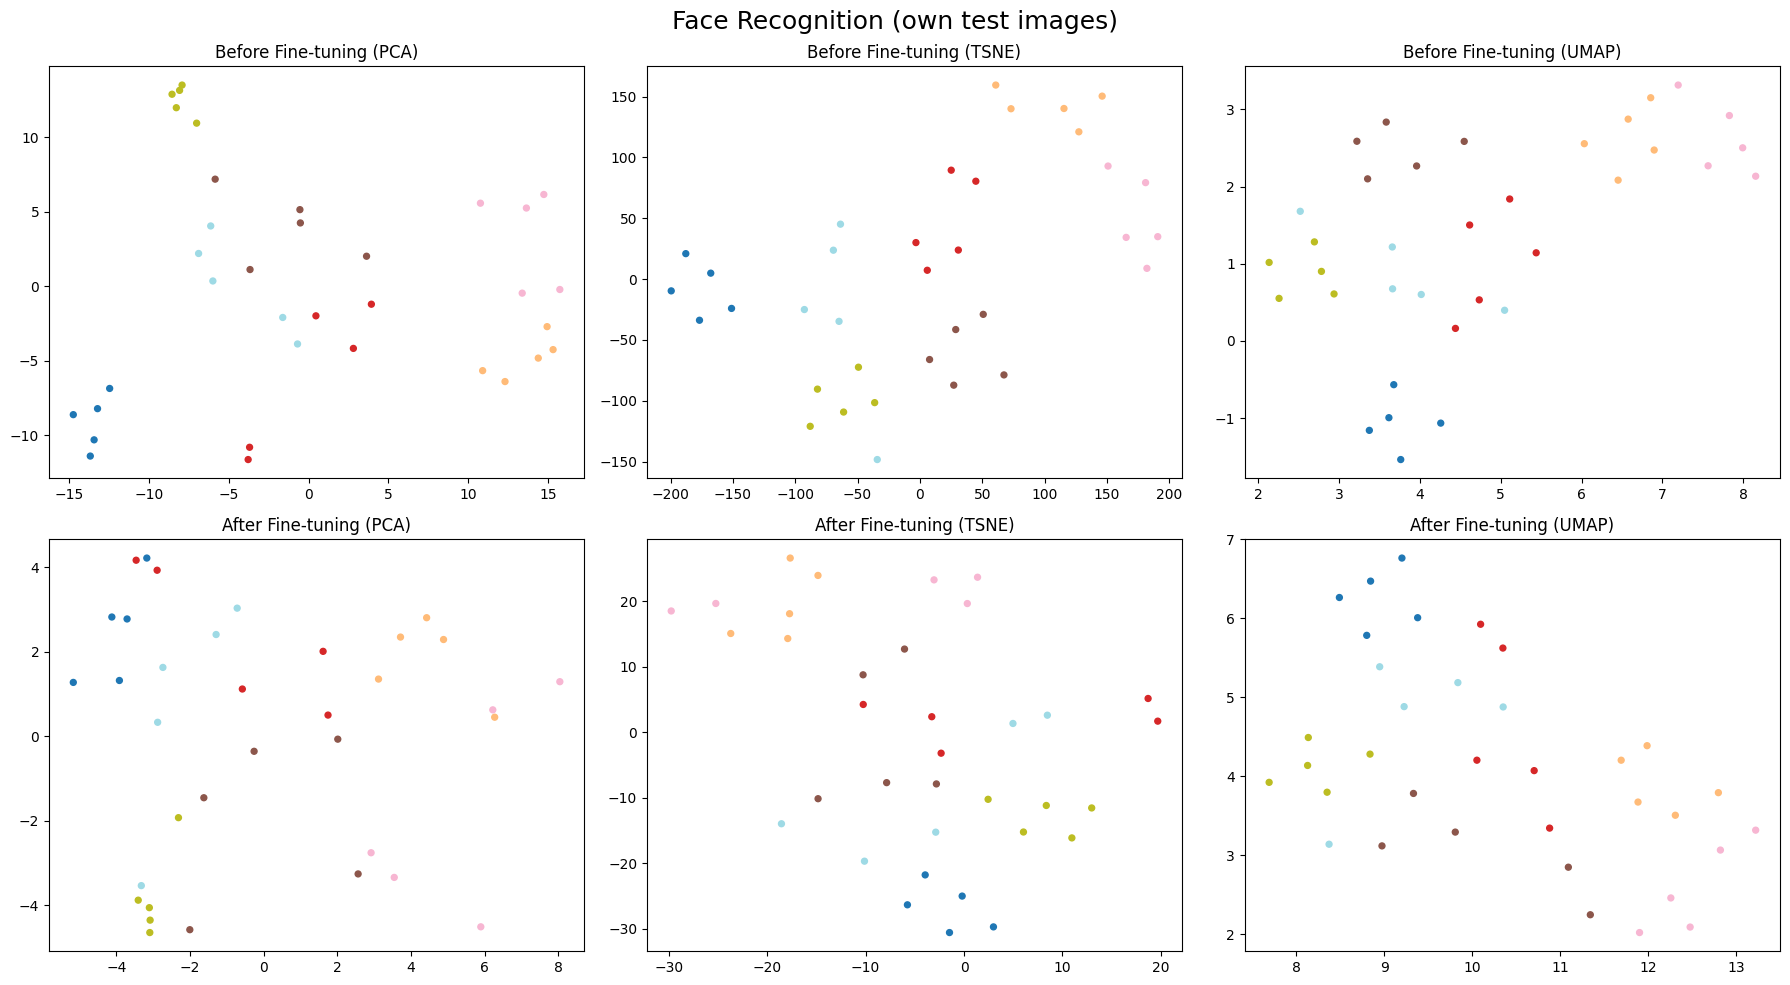

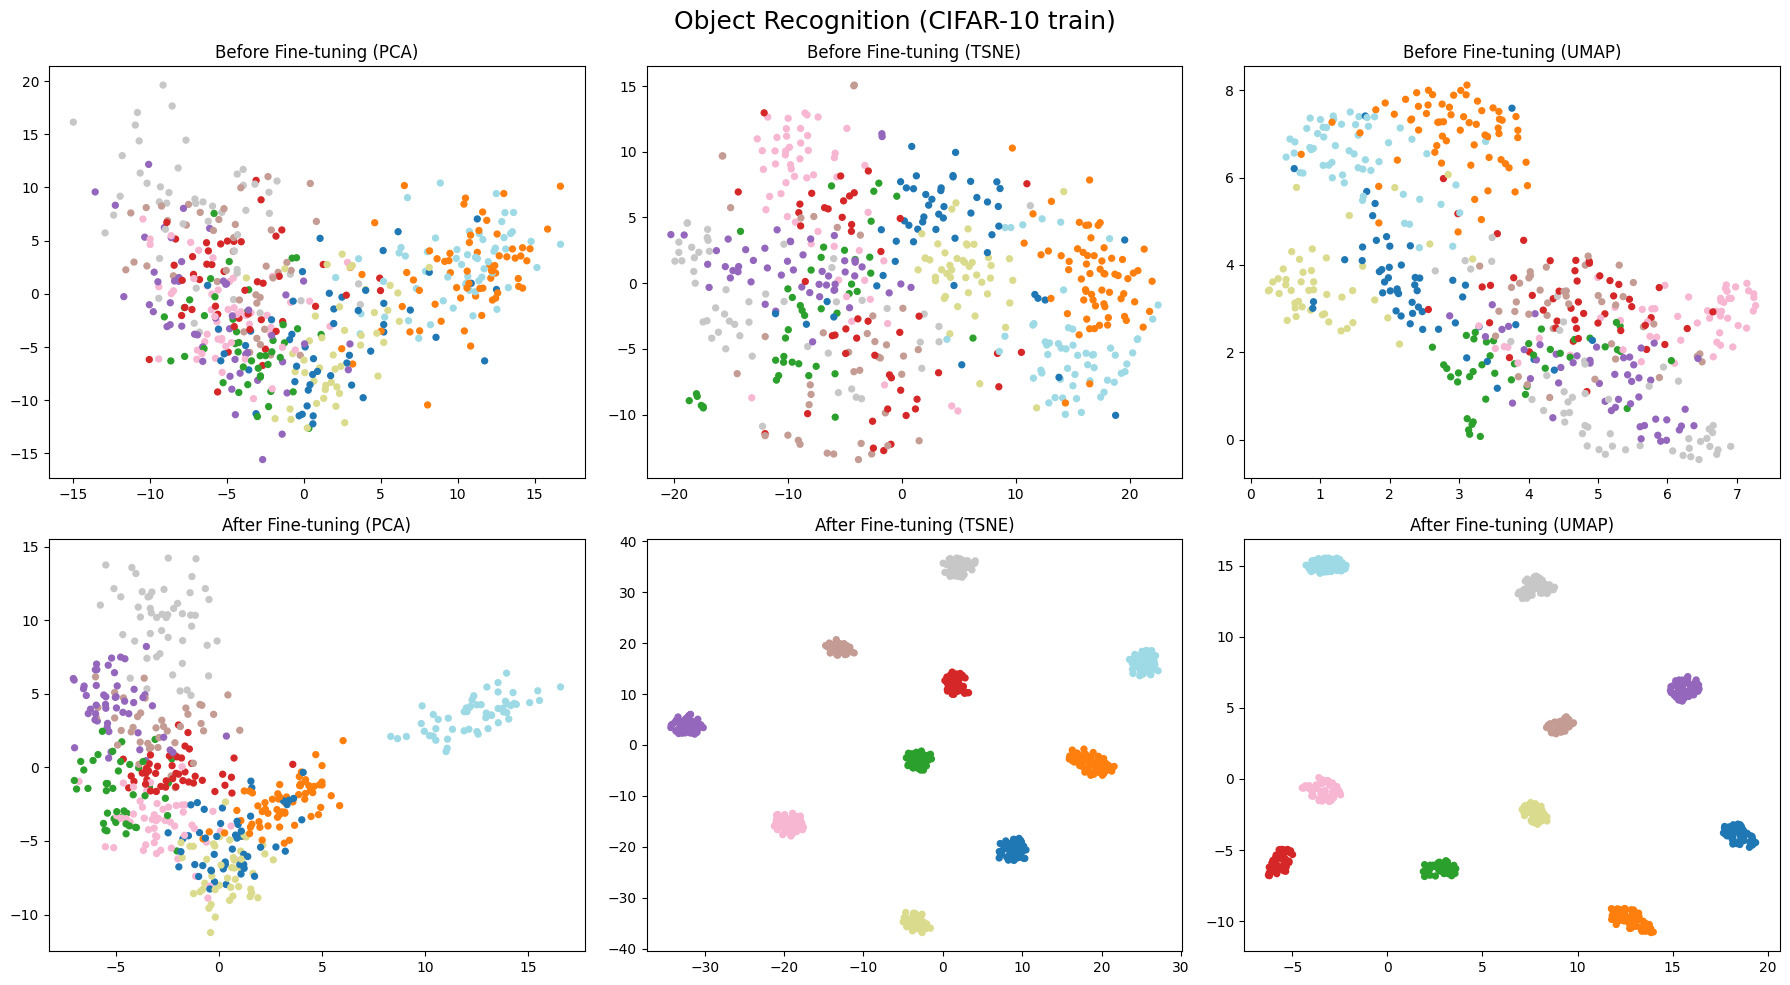

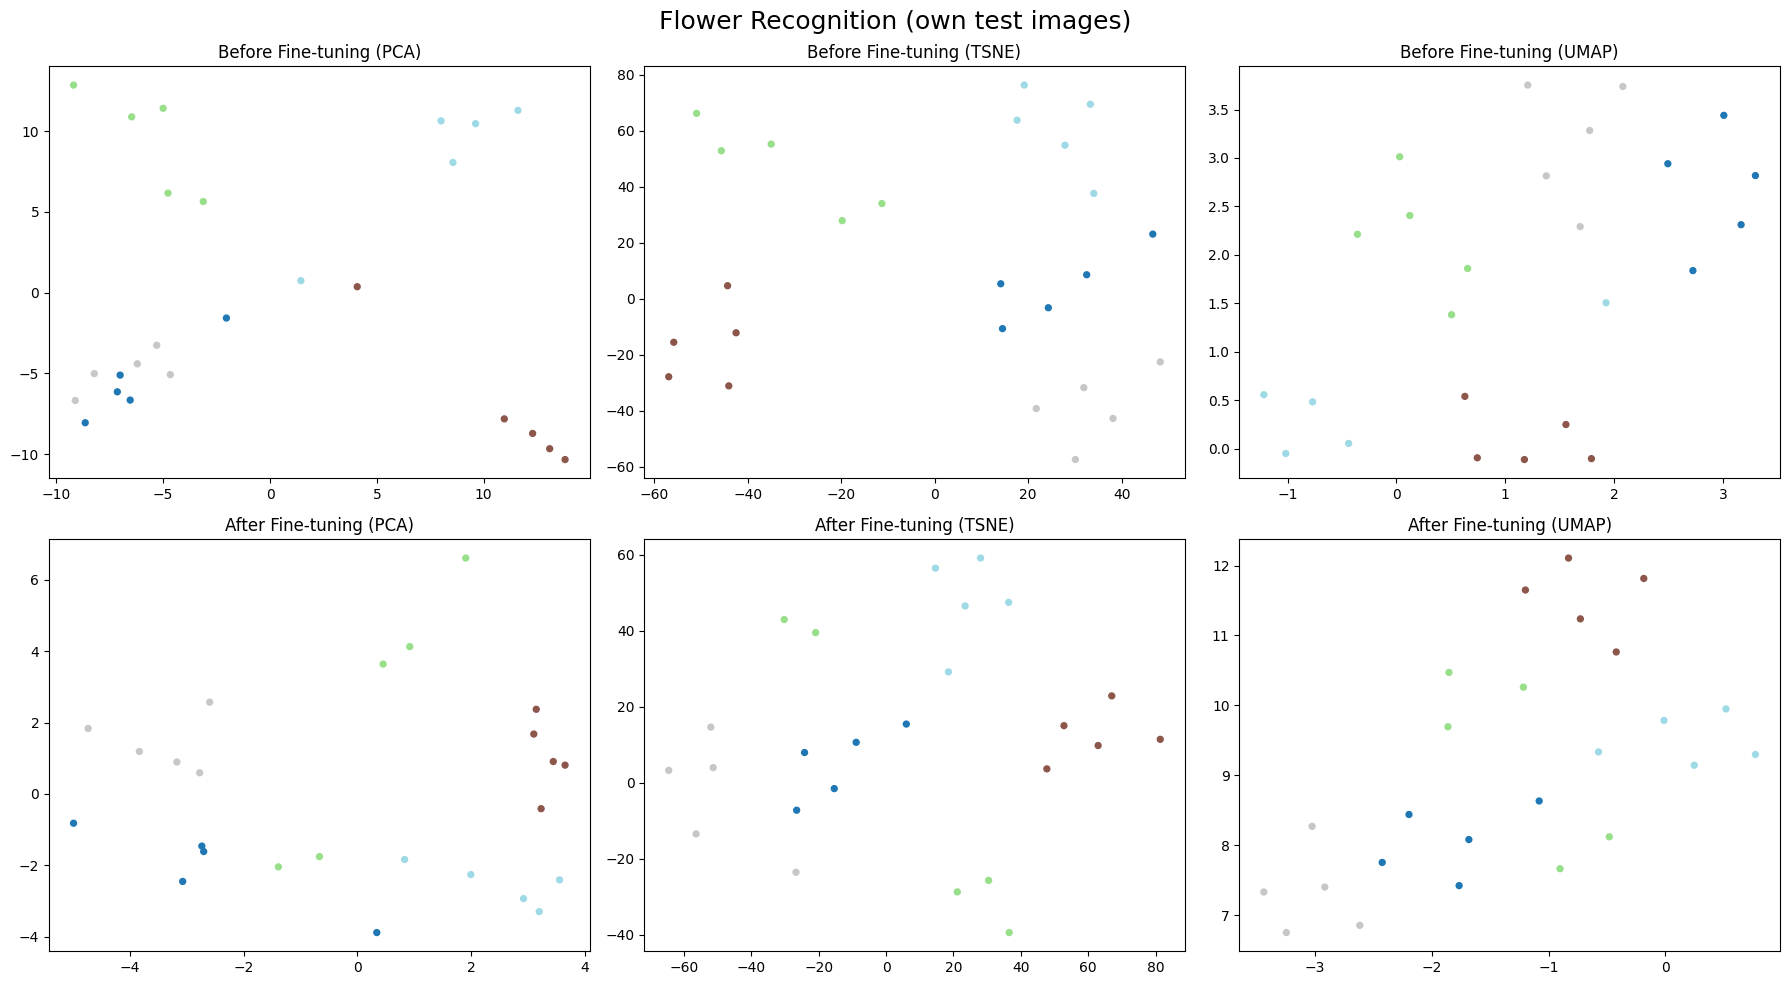

In [22]:
def compare_before_after(before, after, labels, title):
    methods = ["PCA", "TSNE", "UMAP"]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for i, m in enumerate(methods):
        axes[0, i].scatter(before[m][:, 0], before[m][:, 1], c=labels, cmap='tab20', s=18)
        axes[0, i].set_title(f"Before Fine-tuning ({m})")

        axes[1, i].scatter(after[m][:, 0], after[m][:, 1], c=labels, cmap='tab20', s=18)
        axes[1, i].set_title(f"After Fine-tuning ({m})")

    plt.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()


compare_before_after(face_before_reduced, face_after_reduced, lbl_face_val, "Face Recognition (LFW validation)")
compare_before_after(face_test_before_reduced, face_test_after_reduced, lbl_face_test, "Face Recognition (own test images)")
compare_before_after(cifar_before_reduced, cifar_after_reduced, lbl_cifar, "Object Recognition (CIFAR-10 train)")
compare_before_after(flower_test_before_reduced, flower_test_after_reduced, lbl_flower_test, "Flower Recognition (own test images)")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


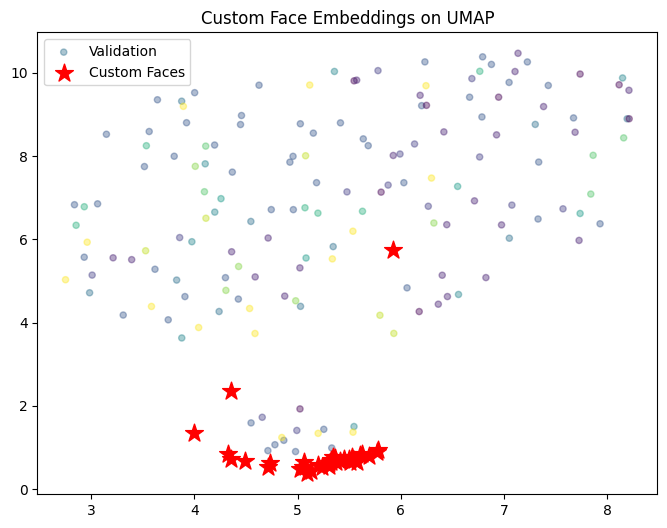

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    face_after_reduced["UMAP"][:,0],
    face_after_reduced["UMAP"][:,1],
    c=lbl_face_val,
    s=20,
    alpha=0.4,
    label="Validation"
)

custom_face_feature = feature_model.predict(X_face_test)

# Instantiate and fit a UMAP reducer on the features used for face_after_reduced
# This ensures the custom faces are projected into the same embedding space.
reducer_umap = umap.UMAP(n_neighbors=10, min_dist=0.3, random_state=RANDOM_STATE)
# Need to fit the reducer on the original features, not the already reduced ones
reducer_umap.fit(features_face_after)

custom_face_umap = reducer_umap.transform(custom_face_feature)

plt.scatter(
    custom_face_umap[:,0],
    custom_face_umap[:,1],
    c='red',
    marker='*',
    s=180,
    label='Custom Faces'
)

plt.legend()
plt.title("Custom Face Embeddings on UMAP")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step


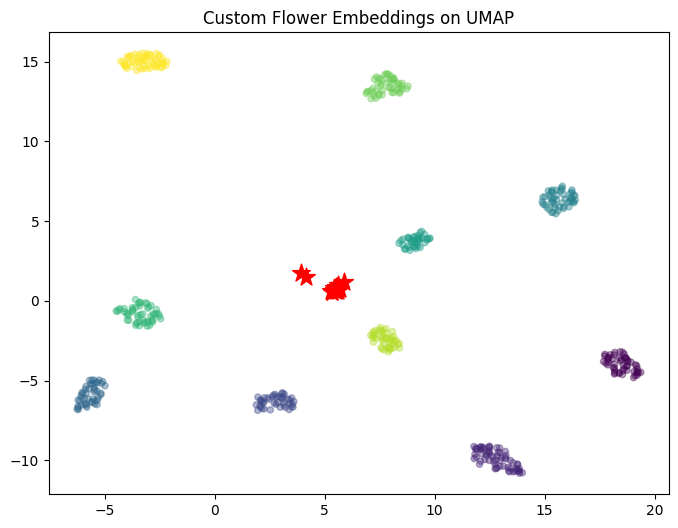

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    cifar_after_reduced["UMAP"][:,0],
    cifar_after_reduced["UMAP"][:,1],
    c=lbl_cifar,
    s=20,
    alpha=0.4
)

custom_feature = feature_model_cifar.predict(X_flower_test)

custom_umap = reducer_umap.transform(custom_feature)

plt.scatter(
    custom_umap[:,0],
    custom_umap[:,1],
    c='red',
    marker='*',
    s=180
)

plt.title("Custom Flower Embeddings on UMAP")
plt.show()

## 8. Quantitative Comparison (Silhouette Score)
Silhouette score ranges roughly from -1 to 1; higher values indicate tighter, better-separated clusters. This gives a numeric backbone to the qualitative "before vs after" and "PCA vs t-SNE vs UMAP" discussion below.

In [23]:
import pandas as pd

rows = []
rows += silhouette_table(face_before_reduced, lbl_face_val, "Face-Val-BEFORE")
rows += silhouette_table(face_after_reduced, lbl_face_val, "Face-Val-AFTER")
rows += silhouette_table(face_test_before_reduced, lbl_face_test, "Face-Test-BEFORE")
rows += silhouette_table(face_test_after_reduced, lbl_face_test, "Face-Test-AFTER")
rows += silhouette_table(cifar_before_reduced, lbl_cifar, "CIFAR-BEFORE")
rows += silhouette_table(cifar_after_reduced, lbl_cifar, "CIFAR-AFTER")
rows += silhouette_table(flower_test_before_reduced, lbl_flower_test, "Flower-Test-BEFORE")
rows += silhouette_table(flower_test_after_reduced, lbl_flower_test, "Flower-Test-AFTER")

silhouette_df = pd.DataFrame(rows, columns=["Setting", "Method", "Silhouette Score"])
silhouette_df_pivot = silhouette_df.pivot(index="Setting", columns="Method", values="Silhouette Score")
silhouette_df_pivot


Method,PCA,TSNE,UMAP
Setting,,,
CIFAR-AFTER,0.213067,0.899151,0.885182
CIFAR-BEFORE,-0.096173,0.047916,0.097575
Face-Test-AFTER,0.102608,0.146065,0.230410
Face-Test-BEFORE,0.411021,0.450400,0.382830
Face-Val-AFTER,-0.297236,-0.306032,-0.310394
Face-Val-BEFORE,-0.225749,-0.288577,-0.264564
Flower-Test-AFTER,0.343470,0.365948,0.327367
Flower-Test-BEFORE,0.318429,0.541485,0.403168


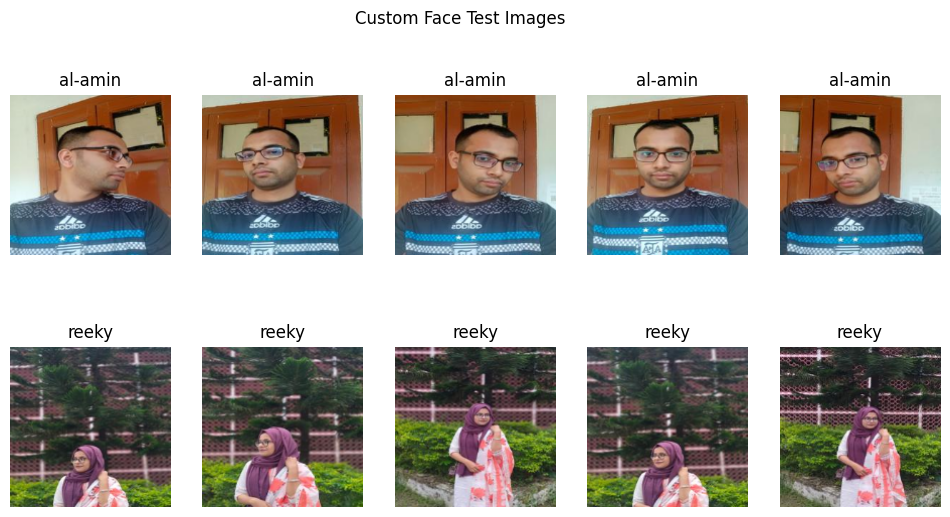

In [25]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

n = min(10, len(X_face_test))

for i in range(n):
    plt.subplot(2,5,i+1)
    # Rescale image data from [-1, 1] to [0, 1] for display
    display_image = (X_face_test[i] + 1) / 2
    plt.imshow(display_image)
    plt.title(face_test_classes[y_face_test[i]])
    plt.axis("off")

plt.suptitle("Custom Face Test Images")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
              precision    recall  f1-score   support

     al-amin       0.00      0.00      0.00         5
       reeky       0.50      0.40      0.44         5
        saba       0.09      0.20      0.12         5
       sania       0.00      0.00      0.00         5
      shawda       0.00      0.00      0.00         5
      shawon       0.00      0.00      0.00         5
       sifat       0.00      0.00      0.00         5

   micro avg       0.11      0.09      0.10        35
   macro avg       0.08      0.09      0.08        35
weighted avg       0.08      0.09      0.08        35



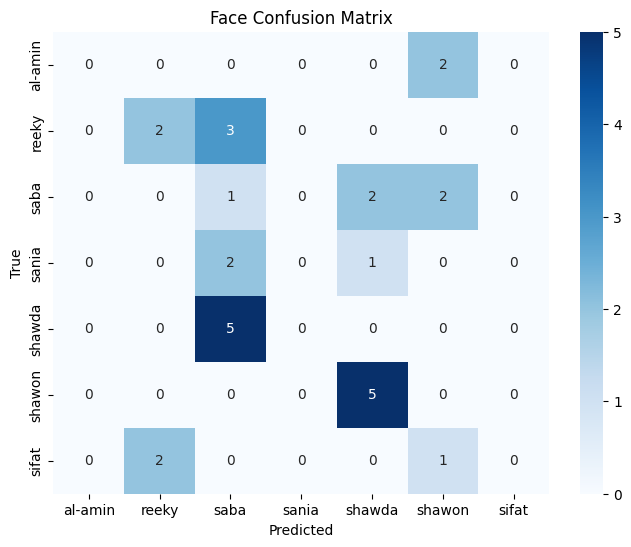

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

pred = np.argmax(model.predict(X_face_test), axis=1)

print(classification_report(
    y_face_test,
    pred,
    target_names=face_test_classes,
    labels=np.unique(y_face_test),
    zero_division=0.0 # Suppress UndefinedMetricWarning by explicitly setting zero_division
))

cm = confusion_matrix(y_face_test, pred, labels=np.unique(y_face_test))

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=face_test_classes,
            yticklabels=face_test_classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Face Confusion Matrix")
plt.show()

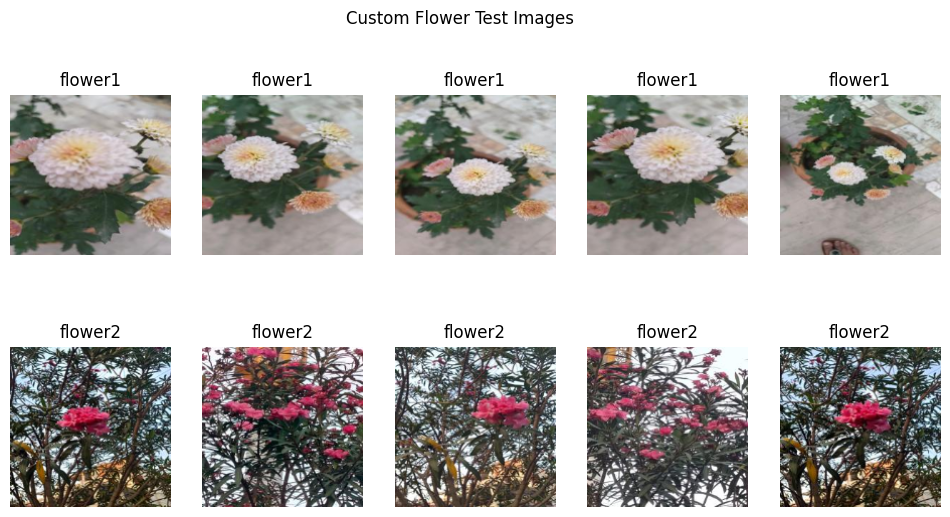

In [31]:
plt.figure(figsize=(12,6))

n = min(10, len(X_flower_test))

for i in range(n):
    plt.subplot(2,5,i+1)
    # Rescale image data from [-1, 1] to [0, 1] for display
    display_image = (X_flower_test[i] + 1) / 2
    plt.imshow(display_image)
    plt.title(flower_test_classes[y_flower_test[i]])
    plt.axis("off")

plt.suptitle("Custom Flower Test Images")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 814ms/step
              precision    recall  f1-score   support

     flower1       0.20      0.20      0.20         5
     flower2       0.00      0.00      0.00         5
     flower3       0.29      0.40      0.33         5
     flower4       0.00      0.00      0.00         5
     flower5       0.25      0.40      0.31         5

   micro avg       0.24      0.20      0.22        25
   macro avg       0.15      0.20      0.17        25
weighted avg       0.15      0.20      0.17        25



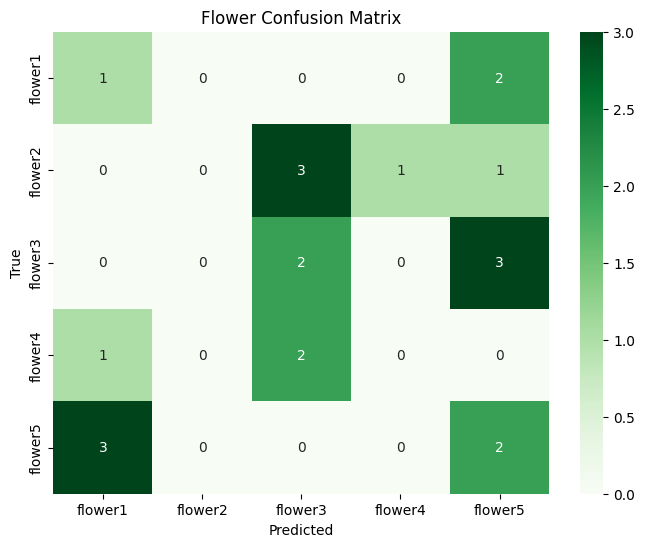

In [34]:
pred = np.argmax(model_cifar.predict(X_flower_test), axis=1)

print(classification_report(
    y_flower_test,
    pred,
    target_names=flower_test_classes,
    labels=np.unique(y_flower_test),
    zero_division=0.0 # Suppress UndefinedMetricWarning by explicitly setting zero_division
))

cm = confusion_matrix(y_flower_test, pred, labels=np.unique(y_flower_test))

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=flower_test_classes,
            yticklabels=flower_test_classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Flower Confusion Matrix")
plt.show()

## 9. Discussion

**9.1 Clustering quality and class separation, before vs. after fine-tuning**

Before fine-tuning, MobileNetV2's penultimate-layer features are generic ImageNet representations — they encode broad texture/shape statistics rather than identity- or category-specific cues, so classes visibly overlap in all three 2D projections. After fine-tuning on the target task (LFW identities / CIFAR-10 categories), the last 30 layers adapt to task-relevant discriminative cues, and the 2D embeddings should show visibly tighter, more separated clusters, both on the validation split and — more importantly — on the truly held-out custom test images.

**9.2 Intra-class compactness and inter-class separability**

Fine-tuning is expected to improve both:
- *Intra-class compactness*: samples of the same identity/category are pulled closer together in feature space, since the classification loss directly rewards this.
- *Inter-class separability*: the decision boundary pressure pushes different classes apart in the same space that produces the features (since the penultimate layer feeds directly into the softmax layer).

Compare the silhouette scores in Section 8: an increase from BEFORE to AFTER for a given (task, method) pair is direct quantitative evidence of both effects.

**9.3 PCA vs. t-SNE vs. UMAP**

- **PCA** finds a linear, global variance-maximizing projection. It's fast and deterministic but tends to compress cluster structure when the true class boundaries are nonlinear — clusters often look like overlapping blobs, especially BEFORE fine-tuning.
- **t-SNE** optimizes to preserve local neighborhoods, at the cost of global distances (cluster sizes/inter-cluster distances aren't meaningful). It usually produces the visually tightest, most distinct-looking clusters, making it best for eyeballing whether classes separate at all — but its structure can be misleading if over-interpreted globally.
- **UMAP** balances local and global structure, runs faster than t-SNE, and its inter-cluster distances are more trustworthy than t-SNE's. It's often the best middle ground for both visual clarity and structural fidelity.

**9.4 Best combination**

Based on the silhouette table, the combination with the **highest AFTER-fine-tuning silhouette score** is the strongest evidence for "which (model + training stage + reduction method) best separates classes" — check Section 8's pivot table and report the specific max in your submission (it will vary slightly run-to-run due to stochastic training/TSNE/UMAP initialization, even with fixed seeds, because of GPU nondeterminism). In general, expect **AFTER fine-tuning + t-SNE or UMAP** to outperform **BEFORE + PCA** by a wide margin, since fine-tuning increases genuine class structure in feature space, and nonlinear reduction methods preserve that structure far better than PCA's linear projection.
